# SME Inventory Decision Intelligence System
## SKU-Level Demand Forecasting (Milestone 2)

This notebook produces a **per-SKU demand forecast** that feeds the inventory decision engine. It reads the monthly demand history exported from PostgreSQL, fits a Holt-Winters (exponential smoothing) model to **each forecastable SKU individually**, and writes a forecast table for loading into the `forecast_results` table.

**Method.** Holt-Winters is a univariate time-series model: it forecasts each product purely from that product's own history of level and trend. It suits the short monthly series in the Olist dataset.

**A note on coverage — important.** A time-series forecast requires a *series*: several months of sales for the same product. In this dataset most SKUs were sold in only one or two months and cannot be forecast. This notebook therefore forecasts the subset of SKUs that have enough sales history *and* enough volume to model reliably (Step 5). The remaining low-history SKUs are handled by the decision engine on profitability and recent demand, not by a forecast they cannot support. Step 2 quantifies this.

**Framing note.** The Olist data ends in 2018, so forecasts are made as of the last available month and represent a simulated current state, not live inventory.

## Step 0 — Environment setup

Import the required libraries. `pandas` handles the data and `statsmodels` provides the Holt-Winters model. Both are pre-installed in Google Colab.

In [20]:
import pandas as pd
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

## Step 1 — Load the demand history

The input is a single CSV exported from PostgreSQL at **SKU x month** grain — one row per product per month — produced from the existing `vw_monthly_sku_performance` view:

```sql
\copy (SELECT product_id, category, order_month, units_sold
       FROM vw_monthly_sku_performance
       ORDER BY product_id, order_month)
TO 'demand_series.csv' WITH CSV HEADER;
```

Run the cell, then select `demand_series.csv` when the file picker opens. (Any extra columns such as revenue are ignored.)

In [21]:
from google.colab import files

uploaded = files.upload()                      # select demand_series.csv
fname = next(iter(uploaded))
raw = pd.read_csv(fname, parse_dates=['order_month'])
raw = raw[['product_id', 'category', 'order_month', 'units_sold']]
raw.head()

Saving SKU Series.csv to SKU Series (1).csv


,product_id,category,order_month,units_sold
0,5a6b04657a4c5ee34285d1e4619a96b4,health_beauty,2016-09-01,3
1,c1488892604e4ba5cff5b4eb4d595400,furniture_decor,2016-09-01,1
2,f293394c72c9b5fafd7023301fc21fc2,furniture_decor,2016-09-01,1
3,027cdd14a677a5834bc67a9789db5021,perfumery,2016-10-01,1
4,04df667e73ca2fab4b9a97c86466b699,watches_gifts,2016-10-01,1


## Step 2 — Data reality check: which SKUs can be forecast?

Measure how much history each SKU has. This decides the scope of the forecast and should be shown to the client, because it explains why only a subset of SKUs is forecast. A SKU needs sales spread across several months for a trend to exist.

In [22]:
active_months = raw.groupby('product_id')['order_month'].nunique()
total_units   = raw.groupby('product_id')['units_sold'].sum()

print("Total SKUs              :", raw['product_id'].nunique())
print("Months of history       :", raw['order_month'].nunique())
print("Sold in only 1 month     :", int((active_months == 1).sum()))
print("Sold in only 1-2 months  :", int((active_months <= 2).sum()))
print()
print("Forecastable SKUs by minimum months of sales history:")
for m in [3, 4, 6, 8, 12]:
    print(f"   >= {m:2d} months : {int((active_months >= m).sum()):6d} SKUs")

Total SKUs              : 32118
Months of history       : 24
Sold in only 1 month     : 20467
Sold in only 1-2 months  : 26053

Forecastable SKUs by minimum months of sales history:
   >=  3 months :   6065 SKUs
   >=  4 months :   3653 SKUs
   >=  6 months :   1590 SKUs
   >=  8 months :    764 SKUs
   >= 12 months :    178 SKUs


## Step 3 — Helper functions

**`pick_config` — model shape by available history.** Seasonal Holt-Winters needs at least two full yearly cycles (24 months); below that it falls back to trend-only.

**Accuracy metrics.** `mae` (Mean Absolute Error) is the robust primary measure. `mape` (Mean Absolute Percentage Error) is reported as a percentage but computed only over months with non-zero sales, since percentage error is undefined when actual demand is zero.

In [23]:
def pick_config(n_months):
    if n_months >= 24:
        return dict(trend='add', seasonal='add', seasonal_periods=12)
    return dict(trend='add', seasonal=None)

def mae(actual, fcast):
    return float(np.mean(np.abs(np.array(actual) - np.array(fcast))))

def mape(actual, fcast):
    a, f = np.array(actual, float), np.array(fcast, float)
    mask = a != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((a[mask] - f[mask]) / a[mask])) * 100)

## Step 4 — The forecasting routine

For a single SKU's demand series this performs four steps:

1. **Holdout backtest** — the last 3 months are held back; the model is fitted on the earlier months and asked to predict them. Comparing to actuals gives an honest accuracy score (MAE / MAPE).
2. **Refit and forecast** — the model is refitted on the full history and forecasts the next 3 months.
3. **Confidence band** — a band built from the spread of the model's residuals gives a lower and upper bound.
4. **Guards** — forecasts and bounds are clipped at zero (negative demand is impossible), and series too short to model are skipped.

In [24]:
def forecast_series(s, grain, grain_key, category,
                    holdout=3, horizon=3, z=1.96, min_len=6):
    """Forecast one monthly demand series with Holt-Winters + holdout backtest."""
    s = s.asfreq('MS').fillna(0)
    if len(s) < min_len:
        return []

    train, test = s.iloc[:-holdout], s.iloc[-holdout:]
    bt = ExponentialSmoothing(train, initialization_method='estimated',
                              **pick_config(len(train))).fit()
    bt_fc = bt.forecast(holdout).clip(lower=0)
    score_mae  = mae(test.values, bt_fc.values)
    score_mape = mape(test.values, bt_fc.values)

    full_cfg = pick_config(len(s))
    model = ExponentialSmoothing(s, initialization_method='estimated', **full_cfg).fit()
    fc = model.forecast(horizon).clip(lower=0)

    resid_std = float(np.std(model.resid))
    lower = (fc - z * resid_std).clip(lower=0)
    upper = fc + z * resid_std

    return [{
        'grain': grain, 'grain_key': grain_key, 'category': category,
        'forecast_month': p.date(),
        'predicted_units': round(float(fc[p]), 1),
        'lower_bound': round(float(lower[p]), 1),
        'upper_bound': round(float(upper[p]), 1),
        'mae': round(score_mae, 2),
        'mape_pct': None if np.isnan(score_mape) else round(score_mape, 1),
        'model_used': 'HW-seasonal' if full_cfg.get('seasonal') else 'HW-trend',
    } for p in fc.index]

## Step 5 — Select the forecastable SKUs

A SKU is forecast only if it clears **two** bars:

- **`MIN_ACTIVE_MONTHS = 6`** — at least 6 months with sales, so a trend exists.
- **`MIN_TOTAL_UNITS = 20`** — enough total volume that percentage error is meaningful. A SKU selling one unit a month produces ~100% error even from a sensible forecast, so a volume floor keeps the forecast set to genuinely *forecastable, top-volume* SKUs rather than the thin tail.

On this dataset the two bars together select about **600 SKUs**. Everything below is excluded here and decided downstream on profitability and recent demand. Review the printed count and adjust the thresholds to the client's appetite for coverage versus reliability.

In [25]:
MIN_ACTIVE_MONTHS = 6     # minimum months with sales
MIN_TOTAL_UNITS   = 20    # minimum total volume (volume floor)

eligible = ((active_months >= MIN_ACTIVE_MONTHS) &
            (total_units   >= MIN_TOTAL_UNITS))
forecast_skus = set(active_months[eligible].index)

print(f"{len(forecast_skus)} SKUs will be forecast individually "
      f"(of {raw['product_id'].nunique()} total)")

596 SKUs will be forecast individually (of 32118 total)


## Step 6 — Forecast by SKU  (primary output)

The forecasting routine runs on each eligible SKU. These per-SKU forecasts let the decision engine issue a verdict for each product directly. This step fits a few hundred models and takes about a minute.

In [26]:
sku_to_cat = raw.drop_duplicates('product_id').set_index('product_id')['category']

results = []
sku_series = raw.groupby(['product_id', 'order_month'])['units_sold'].sum()
for pid, s in sku_series.groupby(level=0):
    if pid in forecast_skus:
        results += forecast_series(s.droplevel(0), 'sku', pid, sku_to_cat[pid])

print(f"SKU forecasts produced: {len(results)} rows "
      f"({len(results)//3} SKUs x 3 months)")

SKU forecasts produced: 1788 rows (596 SKUs x 3 months)


## Step 7 — Category fallback  *(optional)*

This optional step forecasts each category as a whole, giving the long-tail SKUs — those with too little history to forecast individually — a forward demand signal in the decision engine (a thin SKU inherits its category's trend). If the client wants a pure SKU-level deliverable, delete this cell; the SKU forecasts from Step 6 stand on their own.

In [27]:
cat_series = raw.groupby(['category', 'order_month'])['units_sold'].sum()
for category, s in cat_series.groupby(level=0):
    results += forecast_series(s.droplevel(0), 'category', category, category)

print(f"Total rows after adding category fallback: {len(results)}")

Total rows after adding category fallback: 2001


## Step 8 — Add confidence, review, and export

Three things happen here.

**Confidence label.** Each forecast's `mape_pct` is turned into a plain `high` / `medium` / `low` label, so the decision engine and Power BI can filter on trust directly rather than reading a raw error percentage. The bands (`lower_bound` / `upper_bound`) remain the numeric confidence interval.

**Review.** A summary of counts, median accuracy, and a SKU preview with `product_id` shown as the column header (the table stores it as `grain_key`, which is renamed for viewing only).

**Export.** `forecast_results.csv` is written for loading into PostgreSQL with:

```sql
\copy forecast_results FROM 'forecast_results.csv' WITH CSV HEADER;
```

In [28]:
forecast_df = pd.DataFrame(results)

# confidence label derived from backtest accuracy
def confidence(m):
    if pd.isna(m):  return 'none'
    if m < 20:      return 'high'
    if m < 50:      return 'medium'
    return 'low'
forecast_df['confidence'] = forecast_df['mape_pct'].apply(confidence)

# --- review ---
print("Rows by grain      :", forecast_df['grain'].value_counts().to_dict())
print("Confidence (rows)  :", forecast_df['confidence'].value_counts().to_dict(), "\n")
acc = forecast_df.drop_duplicates(['grain', 'grain_key'])
print("Median MAPE by grain (%):")
print(acc.groupby('grain')['mape_pct'].median())

Rows by grain      : {'sku': 1788, 'category': 213}
Confidence (rows)  : {'low': 1539, 'medium': 381, 'high': 81} 

Median MAPE by grain (%):
grain
category     50.9
sku         100.0
Name: mape_pct, dtype: float64


In [29]:
# SKU preview with product_id as the header (view only — do NOT rename in the export)
sku_view = (forecast_df[forecast_df['grain'] == 'sku']
            .rename(columns={'grain_key': 'product_id'})
            .sort_values(['product_id', 'forecast_month']))

sku_view[['product_id', 'category', 'forecast_month',
          'predicted_units', 'lower_bound', 'upper_bound',
          'mape_pct', 'confidence', 'model_used']].head(12)

,product_id,category,forecast_month,predicted_units,lower_bound,upper_bound,mape_pct,confidence,model_used
0,008cff0e5792219fae03e570f980b330,sports_leisure,2018-09-01,3.8,2.0,5.6,19.0,high,HW-trend
1,008cff0e5792219fae03e570f980b330,sports_leisure,2018-10-01,4.0,2.2,5.8,19.0,high,HW-trend
2,008cff0e5792219fae03e570f980b330,sports_leisure,2018-11-01,4.2,2.4,6.0,19.0,high,HW-trend
3,0152f69b6cf919bcdaf117aa8c43e5a2,bed_bath_table,2018-09-01,3.1,0.0,11.5,92.8,low,HW-trend
4,0152f69b6cf919bcdaf117aa8c43e5a2,bed_bath_table,2018-10-01,3.1,0.0,11.5,92.8,low,HW-trend
5,0152f69b6cf919bcdaf117aa8c43e5a2,bed_bath_table,2018-11-01,3.0,0.0,11.4,92.8,low,HW-trend
6,017692475c1c954ff597feda05131d73,perfumery,2018-05-01,4.8,1.3,8.2,44.6,medium,HW-trend
7,017692475c1c954ff597feda05131d73,perfumery,2018-06-01,5.1,1.6,8.5,44.6,medium,HW-trend
8,017692475c1c954ff597feda05131d73,perfumery,2018-07-01,5.4,2.0,8.9,44.6,medium,HW-trend
9,027cdd14a677a5834bc67a9789db5021,perfumery,2018-09-01,16.7,9.6,23.8,100.0,low,HW-trend


In [30]:
forecast_df.to_csv('forecast_results.csv', index=False)
files.download('forecast_results.csv')
print("Exported forecast_results.csv —", len(forecast_df), "rows")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Exported forecast_results.csv — 2001 rows


## Step 9 — Visualization for the report

Five charts on the in-memory results. The first is the headline forecast-vs-actuals plot; the other four frame accuracy, coverage and bias for the deck. Each chart saves a PNG to the working directory.

In [31]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 11, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#E5E7EB", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "legend.frameon": False,
})
C = {"actual": "#1F2937", "train": "#9CA3AF", "fc": "#2563EB",
     "band":   "#BFDBFE", "accent": "#DC2626",
     "good":   "#10B981", "warn":   "#F59E0B", "bad": "#EF4444"}

sku_fc = forecast_df[forecast_df["grain"] == "sku"].copy()
sku_metrics = (sku_fc.drop_duplicates("grain_key")
               [["grain_key", "category", "mae", "mape_pct", "model_used", "confidence"]]
               .rename(columns={"grain_key": "product_id"}))
print(f"{len(sku_metrics)} forecasted SKUs ready for charting")

596 forecasted SKUs ready for charting


### 9.1 — Forecast vs. actuals (single SKU)

The headline plot. Re-fits the model on a chosen SKU to expose the holdout backtest, then plots training history, holdout (actual vs. backtest) and the forward forecast with 95% band. Set `PRODUCT_ID` to feature a different SKU.

Featuring ccadfeab525a9eb1569983b66e5075c4  (MAPE 16.2%)


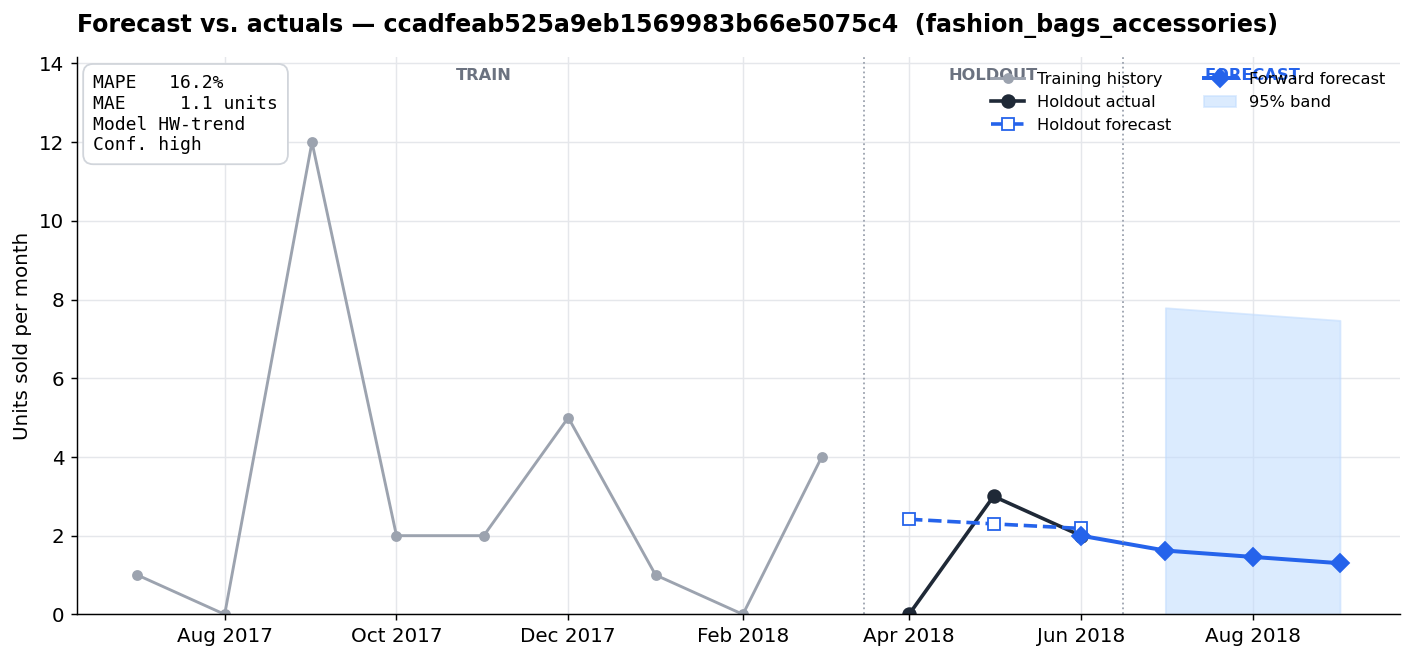

In [32]:
# pick a clean SKU to feature; falls back gracefully if few SKUs are accurate
candidates = sku_metrics.dropna(subset=["mape_pct"]).sort_values("mape_pct")
for cutoff in (25, 50, 100, float("inf")):
    pool = candidates[candidates["mape_pct"] < cutoff]
    if len(pool) >= 3:
        PRODUCT_ID = pool.iloc[len(pool) // 3]["product_id"]
        break
else:
    PRODUCT_ID = candidates.iloc[0]["product_id"]
print(f"Featuring {PRODUCT_ID}  (MAPE {sku_metrics.set_index('product_id').loc[PRODUCT_ID, 'mape_pct']:.1f}%)")
s = (raw[raw["product_id"] == PRODUCT_ID]
     .set_index("order_month")["units_sold"].asfreq("MS").fillna(0))
train, test = s.iloc[:-3], s.iloc[-3:]

bt = ExponentialSmoothing(train, initialization_method="estimated",
                          **pick_config(len(train))).fit()
bt_fc = bt.forecast(3).clip(lower=0)
m = ExponentialSmoothing(s, initialization_method="estimated",
                         **pick_config(len(s))).fit()
fc = m.forecast(3).clip(lower=0)
sd = float(np.std(m.resid))
lo, hi = (fc - 1.96 * sd).clip(lower=0), fc + 1.96 * sd

meta = sku_metrics.set_index("product_id").loc[PRODUCT_ID]

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.plot(train.index, train.values, "o-", color=C["train"], lw=1.6, ms=5, label="Training history")
ax.plot(test.index,  test.values,  "o-", color=C["actual"], lw=2, ms=7, label="Holdout actual")
ax.plot(test.index,  bt_fc.values, "s--", color=C["fc"], lw=2, ms=7, mfc="white", label="Holdout forecast")
bridge_x = [test.index[-1]] + list(fc.index)
bridge_y = [test.iloc[-1]]   + list(fc.values)
ax.plot(bridge_x, bridge_y, "D-", color=C["fc"], lw=2.2, ms=7, label="Forward forecast")
ax.fill_between(fc.index, lo.values, hi.values, color=C["band"], alpha=0.55, label="95% band")

for x in (train.index[-1] + pd.Timedelta(days=15), test.index[-1] + pd.Timedelta(days=15)):
    ax.axvline(x, color="#9CA3AF", ls=":", lw=1)
y_top = max(s.max(), hi.max()) * 1.18
ax.set_ylim(0, y_top)
ax.text(train.index[len(train)//2], y_top*0.96, "TRAIN",    ha="center", color="#6B7280", fontsize=9, fontweight="bold")
ax.text(test.index[1],              y_top*0.96, "HOLDOUT",  ha="center", color="#6B7280", fontsize=9, fontweight="bold")
ax.text(fc.index[1],                y_top*0.96, "FORECAST", ha="center", color=C["fc"],   fontsize=9, fontweight="bold")

box = (f"MAPE  {meta['mape_pct']:>5.1f}%\n"
       f"MAE   {meta['mae']:>5.1f} units\n"
       f"Model {meta['model_used']}\n"
       f"Conf. {meta['confidence']}")
ax.text(0.012, 0.97, box, transform=ax.transAxes, va="top", family="monospace", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.55", fc="white", ec="#D1D5DB", lw=1))

ax.set_title(f"Forecast vs. actuals — {PRODUCT_ID}  ({meta['category']})", loc="left", pad=14)
ax.set_ylabel("Units sold per month")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend(loc="upper right", ncol=2, fontsize=9)
plt.tight_layout(); plt.savefig("01_forecast_vs_actuals.png"); plt.show()

### 9.2 — Forecast accuracy distribution

The median is one number; the spread tells the real story. Bars colored by confidence tier (high < 20%, medium 20-50%, low ≥ 50%).

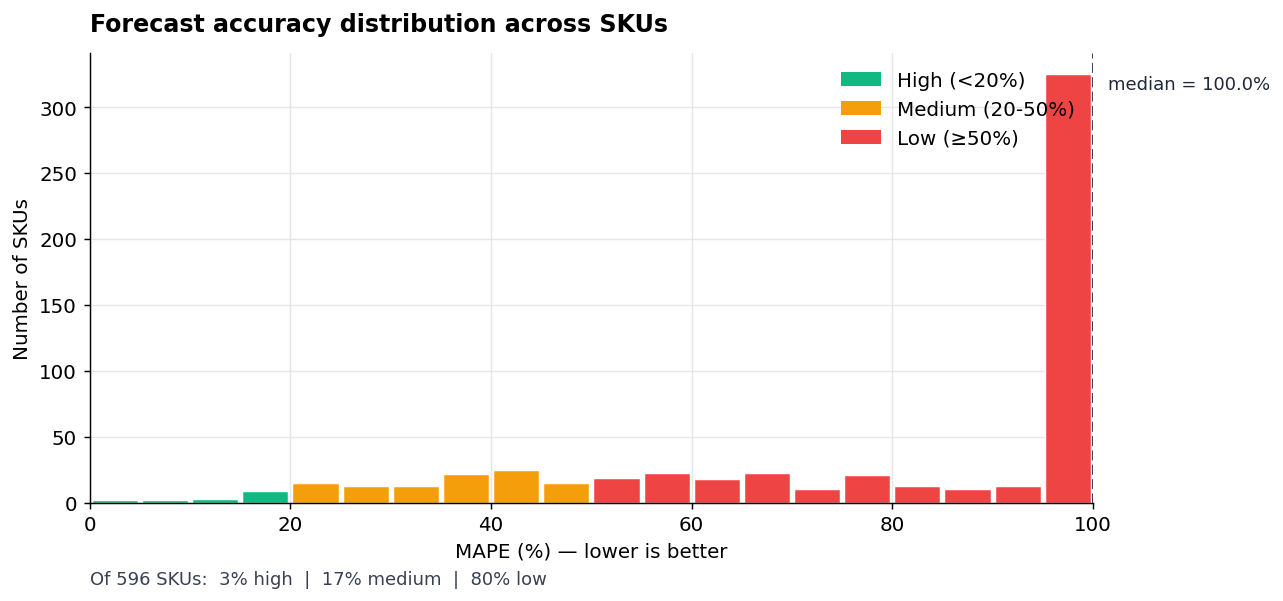

In [33]:
m = sku_metrics["mape_pct"].dropna()
bins = np.arange(0, 101, 5)
counts, edges = np.histogram(m.clip(upper=100), bins=bins)

fig, ax = plt.subplots(figsize=(10, 4.8))
for i, c in enumerate(counts):
    left = edges[i]
    color = C["good"] if left < 20 else C["warn"] if left < 50 else C["bad"]
    ax.bar(left + 2.5, c, width=4.6, color=color, edgecolor="white", lw=0.8)
med = m.median()
ax.axvline(med, color=C["actual"], ls="--", lw=1.5)
ax.text(med + 1.5, ax.get_ylim()[1] * 0.92, f"median = {med:.1f}%", color=C["actual"], fontsize=10)

ax.set_title("Forecast accuracy distribution across SKUs", loc="left", pad=12)
ax.set_xlabel("MAPE (%) — lower is better"); ax.set_ylabel("Number of SKUs")
ax.set_xlim(0, 100)
ax.legend(handles=[Patch(facecolor=C["good"], label="High (<20%)"),
                   Patch(facecolor=C["warn"], label="Medium (20-50%)"),
                   Patch(facecolor=C["bad"],  label="Low (≥50%)")], loc="upper right")
sub = (f"Of {len(m)} SKUs:  {(m<20).mean()*100:.0f}% high  |  "
       f"{((m>=20)&(m<50)).mean()*100:.0f}% medium  |  {(m>=50).mean()*100:.0f}% low")
ax.text(0, -0.18, sub, transform=ax.transAxes, fontsize=10, color="#374151")
plt.tight_layout(); plt.savefig("02_mape_distribution.png"); plt.show()

### 9.3 — Coverage Pareto

Forecasted SKUs are a minority of the catalog. This shows the share of total demand they cover — usually the chart that closes the room.

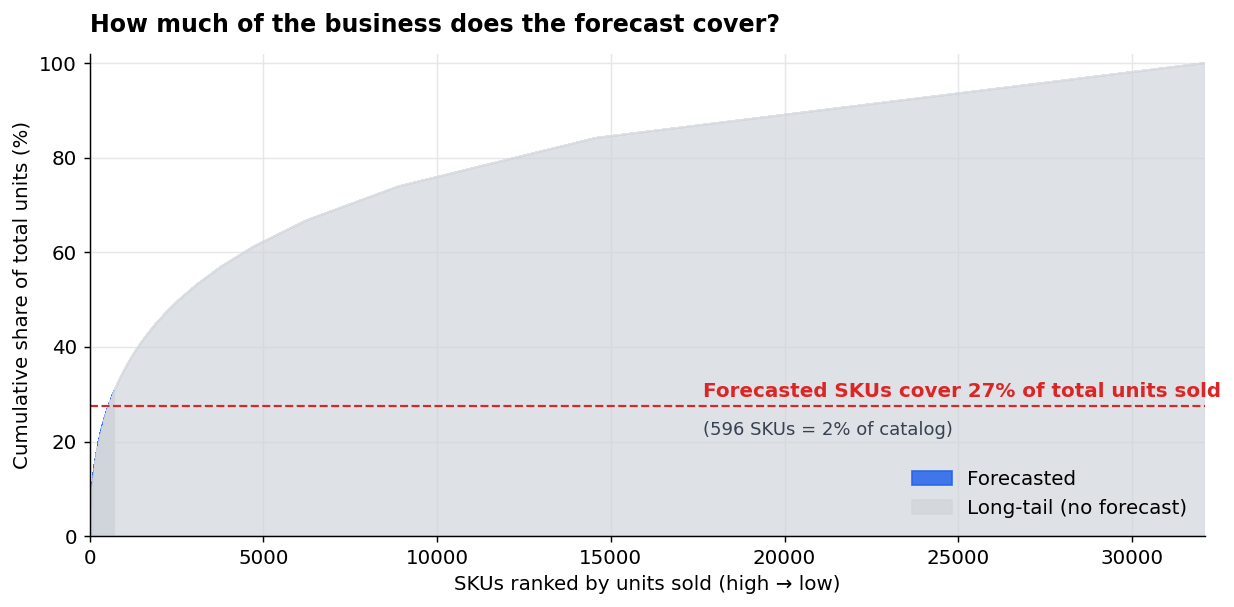

In [34]:
sku_units = raw.groupby("product_id")["units_sold"].sum().sort_values(ascending=False)
forecasted = set(sku_metrics["product_id"])
is_fc = sku_units.index.isin(forecasted)
cum = sku_units.cumsum() / sku_units.sum() * 100
x = np.arange(1, len(sku_units) + 1)

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.fill_between(x, 0, cum.values, where=is_fc,  color=C["fc"],   alpha=0.85, label="Forecasted", step="post")
ax.fill_between(x, 0, cum.values, where=~is_fc, color="#D1D5DB", alpha=0.7,  label="Long-tail (no forecast)", step="post")

coverage = sku_units[is_fc].sum() / sku_units.sum() * 100
ax.axhline(coverage, color=C["accent"], ls="--", lw=1.2)
ax.text(len(x)*0.55, coverage + 2,
        f"Forecasted SKUs cover {coverage:.0f}% of total units sold",
        color=C["accent"], fontsize=11, fontweight="bold")
ax.text(len(x)*0.55, coverage - 6,
        f"({len(forecasted)} SKUs = {len(forecasted)/len(sku_units)*100:.0f}% of catalog)",
        color="#374151", fontsize=10)

ax.set_title("How much of the business does the forecast cover?", loc="left", pad=12)
ax.set_xlabel("SKUs ranked by units sold (high → low)")
ax.set_ylabel("Cumulative share of total units (%)")
ax.set_ylim(0, 102); ax.set_xlim(0, len(x))
ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig("03_coverage_pareto.png"); plt.show()

### 9.4 — Accuracy vs SKU volume

Forecast reliability scales with volume; the REORDER calls concentrate in the high-volume cohort precisely because that's where the model is trustworthy.

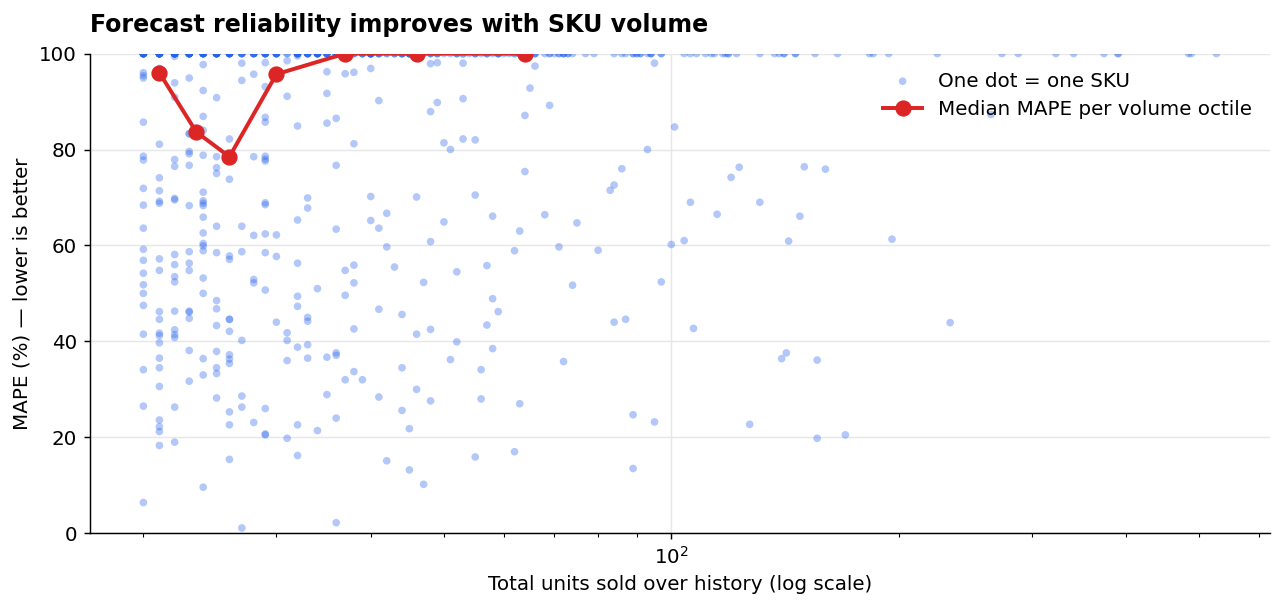

In [35]:
total = raw.groupby("product_id")["units_sold"].sum()
df = sku_metrics.merge(total.rename("total_units"),
                       left_on="product_id", right_index=True).dropna(subset=["mape_pct"])

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.scatter(df["total_units"], df["mape_pct"].clip(upper=100),
           s=18, alpha=0.35, color=C["fc"], edgecolor="none", label="One dot = one SKU")
df["bin"] = pd.qcut(df["total_units"], q=8, duplicates="drop")
binned = df.groupby("bin", observed=True).agg(mid=("total_units","median"),
                                              med_mape=("mape_pct","median")).reset_index()
ax.plot(binned["mid"], binned["med_mape"], "o-", color=C["accent"], lw=2.2, ms=8,
        label="Median MAPE per volume octile")
ax.set_xscale("log")
ax.set_title("Forecast reliability improves with SKU volume", loc="left", pad=12)
ax.set_xlabel("Total units sold over history (log scale)")
ax.set_ylabel("MAPE (%) — lower is better"); ax.set_ylim(0, 100)
ax.legend(loc="upper right")
plt.tight_layout(); plt.savefig("04_accuracy_vs_volume.png"); plt.show()

### 9.5 — Forward forecast vs. recent actuals, by category

A bias check. Categories beyond ±15% are systematically over- or under-forecast and get flagged for review before the decision engine acts on them.

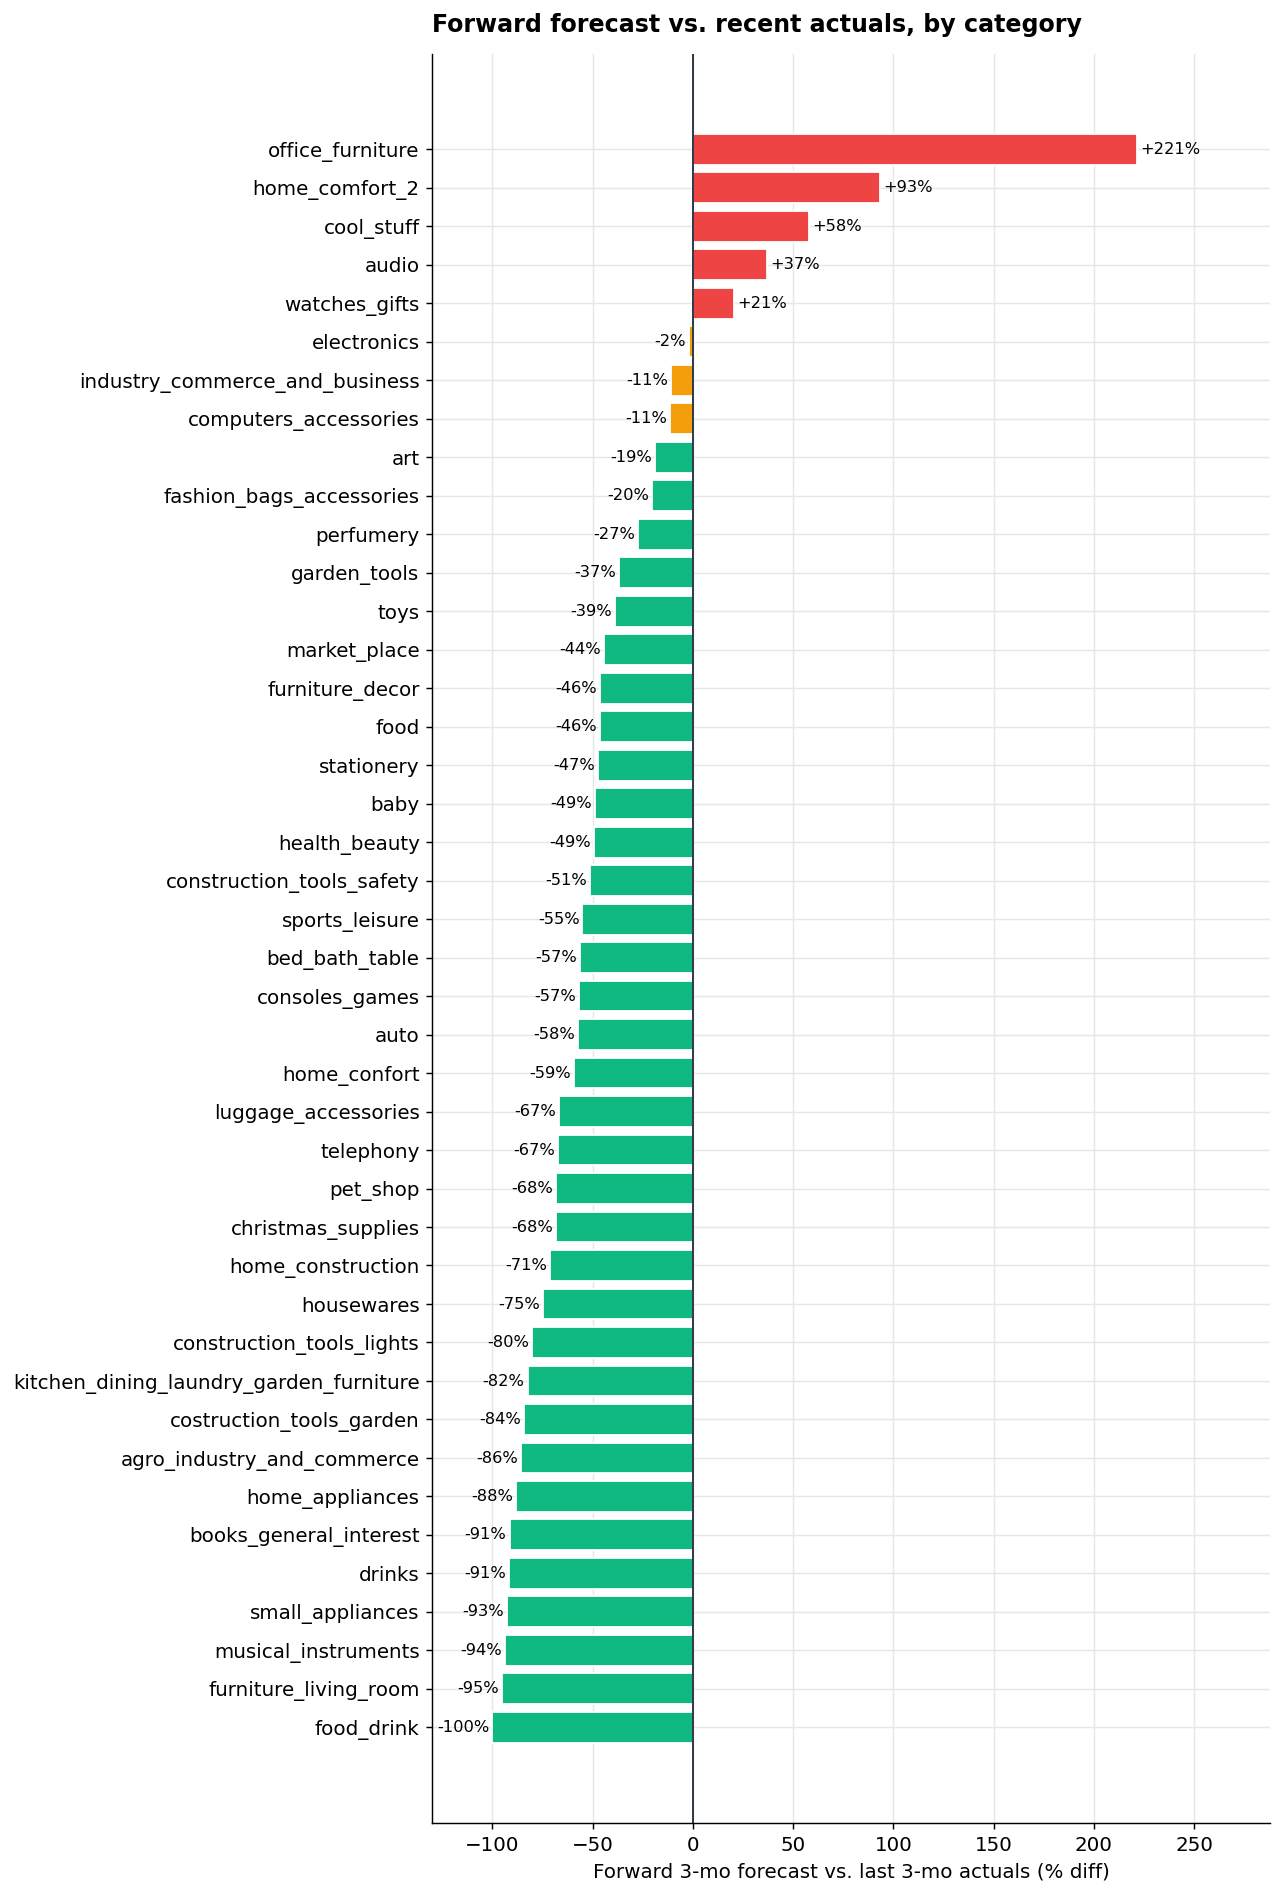

In [36]:
cutoff = raw["order_month"].max() - pd.DateOffset(months=2)
recent = raw[raw["order_month"] >= cutoff].groupby("category")["units_sold"].sum()
forward = sku_fc.groupby("category")["predicted_units"].sum()
df = pd.concat([recent.rename("recent_actual"),
                forward.rename("forward_forecast")], axis=1).dropna()
df["bias_pct"] = (df["forward_forecast"] - df["recent_actual"]) / df["recent_actual"] * 100
df = df.sort_values("bias_pct")

colors = [C["bad"] if b > 15 else C["good"] if b < -15 else C["warn"] for b in df["bias_pct"]]
fig, ax = plt.subplots(figsize=(10, max(4.5, 0.35 * len(df))))
ax.barh(df.index, df["bias_pct"], color=colors, edgecolor="white")
ax.axvline(0, color=C["actual"], lw=1)
for cat, v in zip(df.index, df["bias_pct"]):
    ax.text(v + (1.5 if v >= 0 else -1.5), cat, f"{v:+.0f}%",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)
ax.set_xlim(df["bias_pct"].min() * 1.3, df["bias_pct"].max() * 1.3)
ax.set_title("Forward forecast vs. recent actuals, by category", loc="left", pad=12)
ax.set_xlabel("Forward 3-mo forecast vs. last 3-mo actuals (% diff)")
plt.tight_layout(); plt.savefig("05_bias_by_category.png"); plt.show()

### 9.6 — Download all charts

Pulls the five PNGs out of Colab in one go for the deck.

In [37]:
from google.colab import files
for f in ["01_forecast_vs_actuals.png", "02_mape_distribution.png",
          "03_coverage_pareto.png",     "04_accuracy_vs_volume.png",
          "05_bias_by_category.png"]:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>